In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle; import pytensor
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.config import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_base as wp
from _CO_Oxidation.wrapper_base import plot_posteriors, plot_model_fits, plot_coverages, plot_drc, simulate_fake_data

C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Pd100_base_replicates.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_KOH_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_KOH_in = wp.C_KOH_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    sigma_rel = pm.HalfNormal('sigma_rel', sigma=0.1) # 0.1
    sigma_exp = wp.log_rate_SD_obs 
    sigma_tot = pm.math.sqrt(sigma_rel**2 + sigma_exp**2)
    rate = pm.LogNormal('rate', mu=log_rate, sigma=sigma_tot, observed=wp.rate_obs_matrix)
    return rate

Ag_comp = 1e-4

# ER (!)
Great simple model.

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.64,3
,3000,0,0.66,7
,3000,0,0.57,7
,3000,0,0.55,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  3552.09    59.80
p_loo        4.69        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



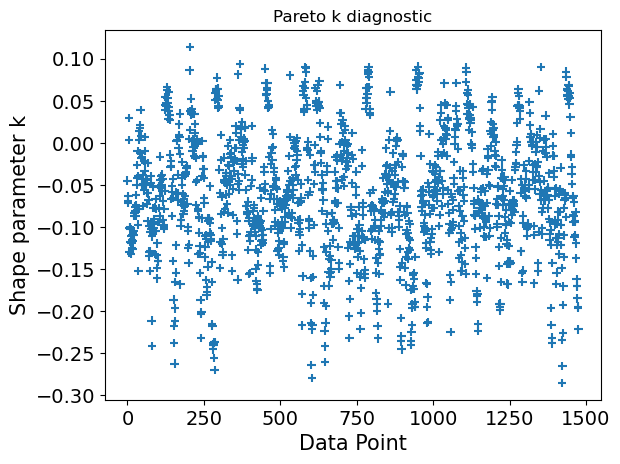

Sampling: [Gact2_0, beta_2, deltaG1_0, deltaG4_0, sigma_rel]


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.147  0.001  -0.148   -0.145        0.0      0.0    2663.0    2809.0    1.0
deltaG4_0  0.110  0.003   0.105    0.115        0.0      0.0    3481.0    3256.0    1.0
beta_2     0.321  0.002   0.317    0.325        0.0      0.0    3508.0    3205.0    1.0
Gact2_0    0.769  0.000   0.768    0.770        0.0      0.0    2902.0    2427.0    1.0
sigma_rel  0.320  0.007   0.306    0.332        0.0      0.0    4299.0    2809.0    1.0

--- Prior-to-Posterior Contraction ---
deltaG1_0: 1.000
deltaG4_0: 1.000
beta_2: 1.000
Gact2_0: 1.000
sigma_rel: 0.988


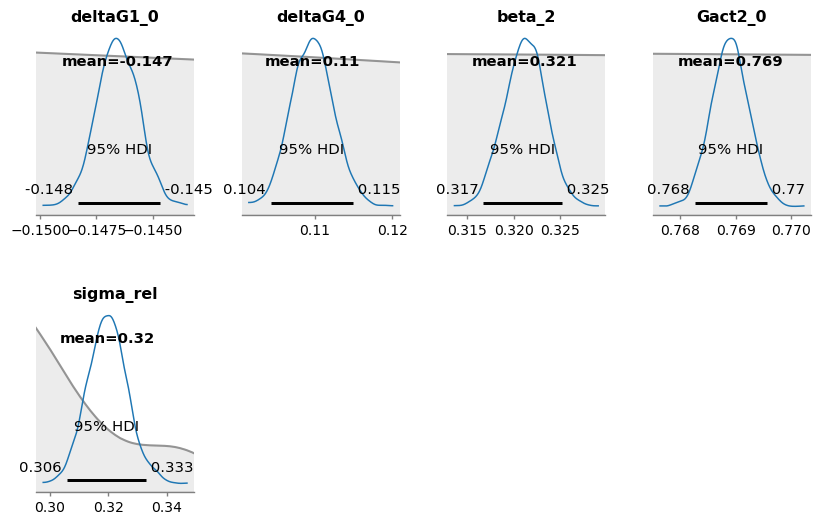

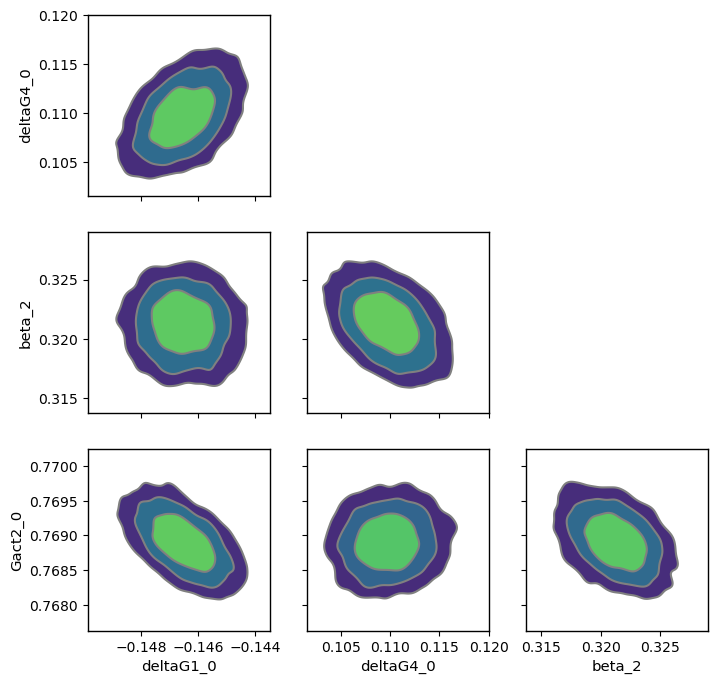

Sampling: [rate]


rate: 0.854


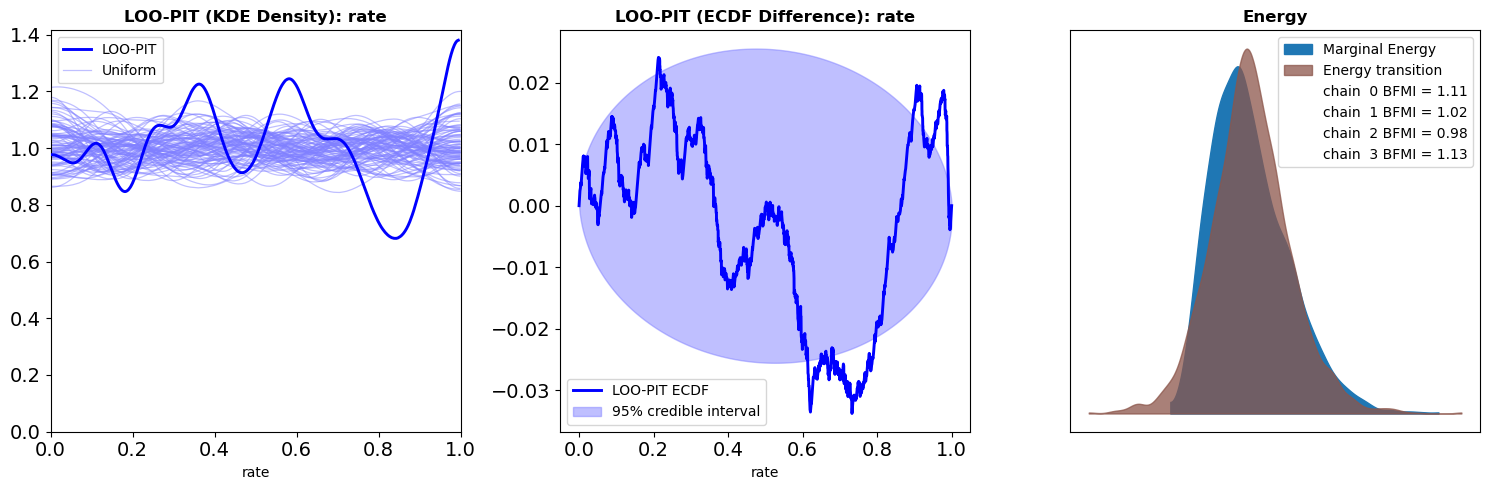

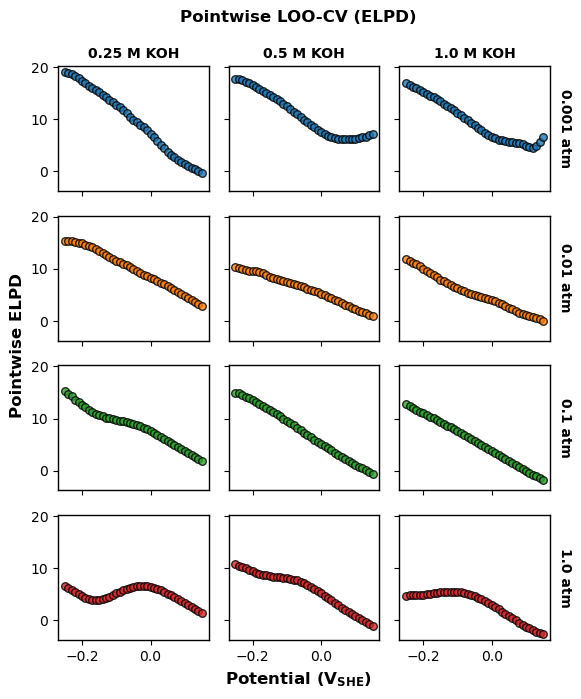

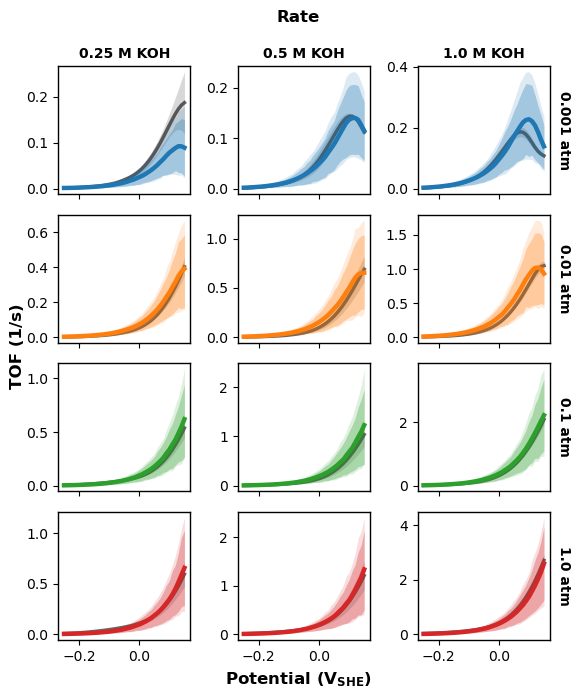

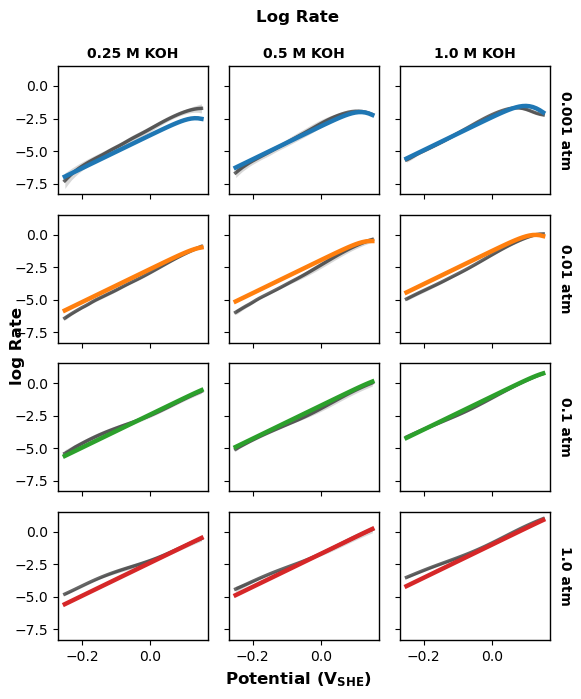

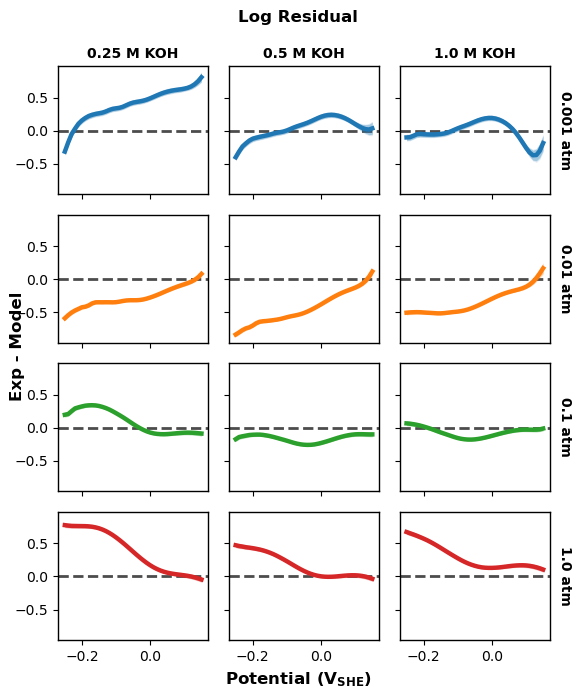

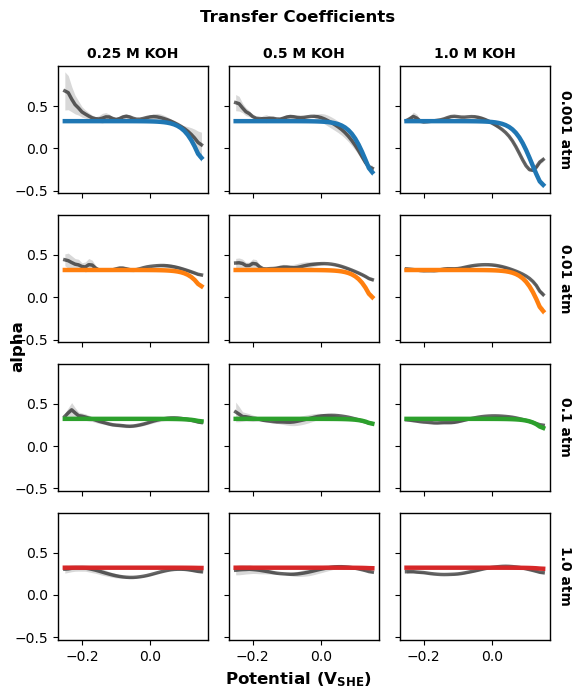

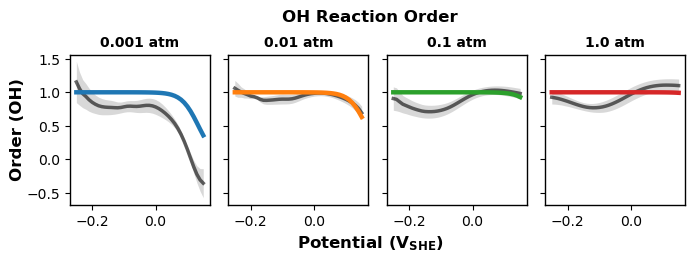

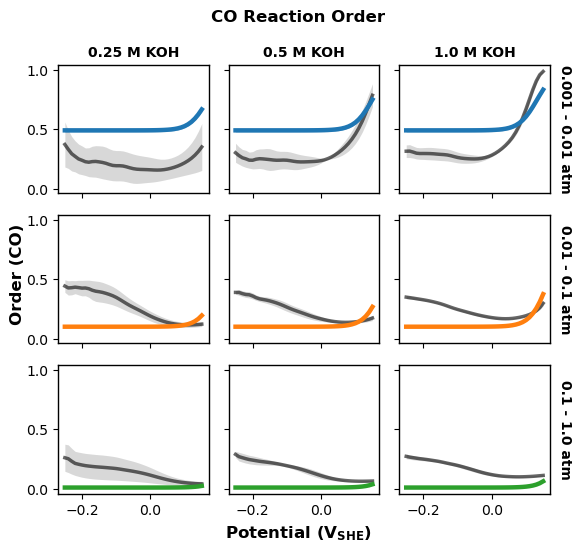

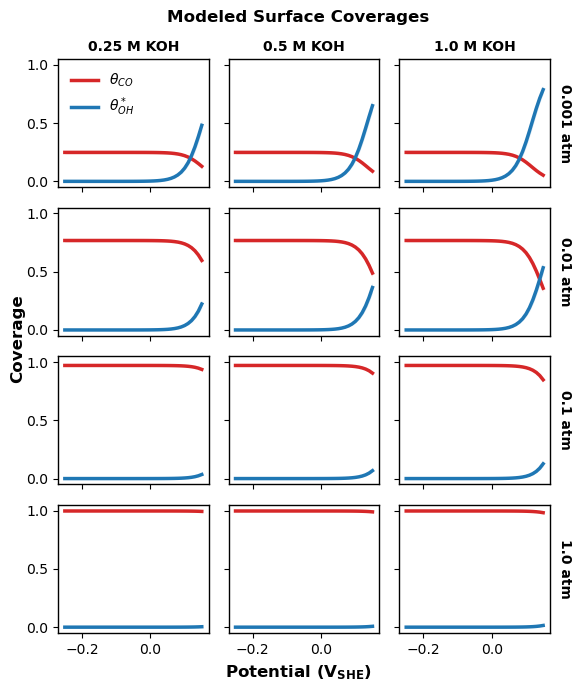

In [2]:
with pm.Model() as ER:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    beta_2 = pm.Uniform('beta_2', lower=0.0, upper=1.0)   
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.7, sigma=0.2, lower=0.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER, loo_ER = fit_and_evaluate(ER)

ppc_ER = plot_posteriors(trace_ER, ER)
plot_model_fits(trace_ER, ppc_ER, loo_ER); plot_coverages(trace_ER)

# LH ER (!!)
LH has significant DRC at high potentials. ELPD diff is significant. Should be the correct solution. 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.52,7
,3000,0,0.50,7
,3000,0,0.52,3
,3000,0,0.53,3


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  3593.60    58.88
p_loo        5.16        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



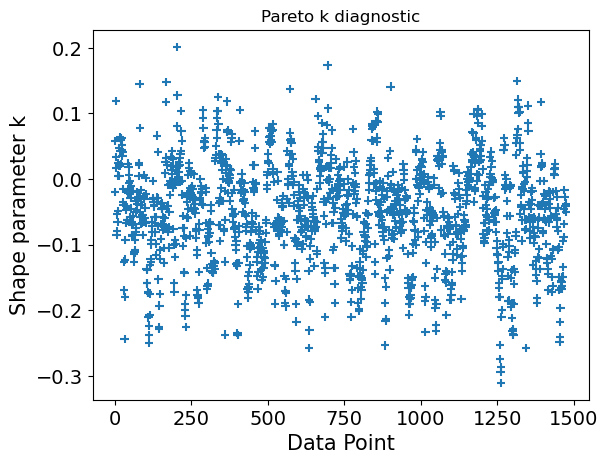

Sampling: [Gact2_ER_0, Gact2_LH_0, beta_2, deltaG1_0, deltaG4_0, sigma_rel]


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.143  0.001  -0.145   -0.142        0.0      0.0    2564.0    2493.0    1.0
deltaG4_0   0.091  0.002   0.087    0.096        0.0      0.0    4380.0    3276.0    1.0
beta_2      0.313  0.002   0.309    0.318        0.0      0.0    3023.0    3024.0    1.0
Gact2_ER_0  0.769  0.000   0.769    0.770        0.0      0.0    3187.0    2809.0    1.0
Gact2_LH_0  0.736  0.003   0.731    0.741        0.0      0.0    2623.0    2528.0    1.0
sigma_rel   0.310  0.007   0.297    0.322        0.0      0.0    5292.0    3015.0    1.0

--- Prior-to-Posterior Contraction ---
deltaG1_0: 1.000
deltaG4_0: 1.000
beta_2: 1.000
Gact2_ER_0: 1.000
Gact2_LH_0: 1.000
sigma_rel: 0.988


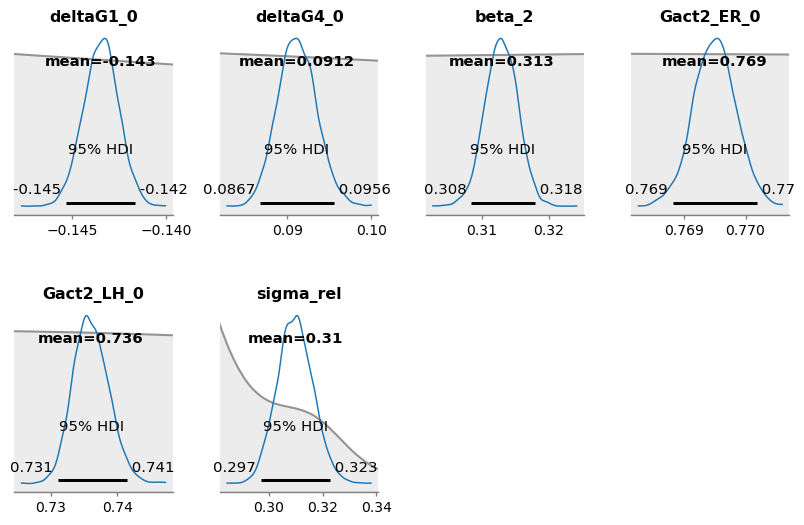

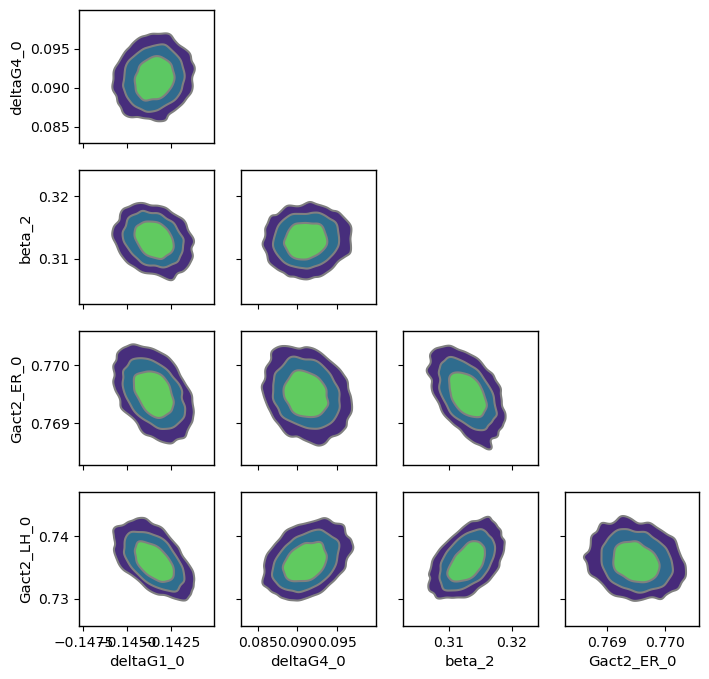

Sampling: [rate]


rate: 0.849


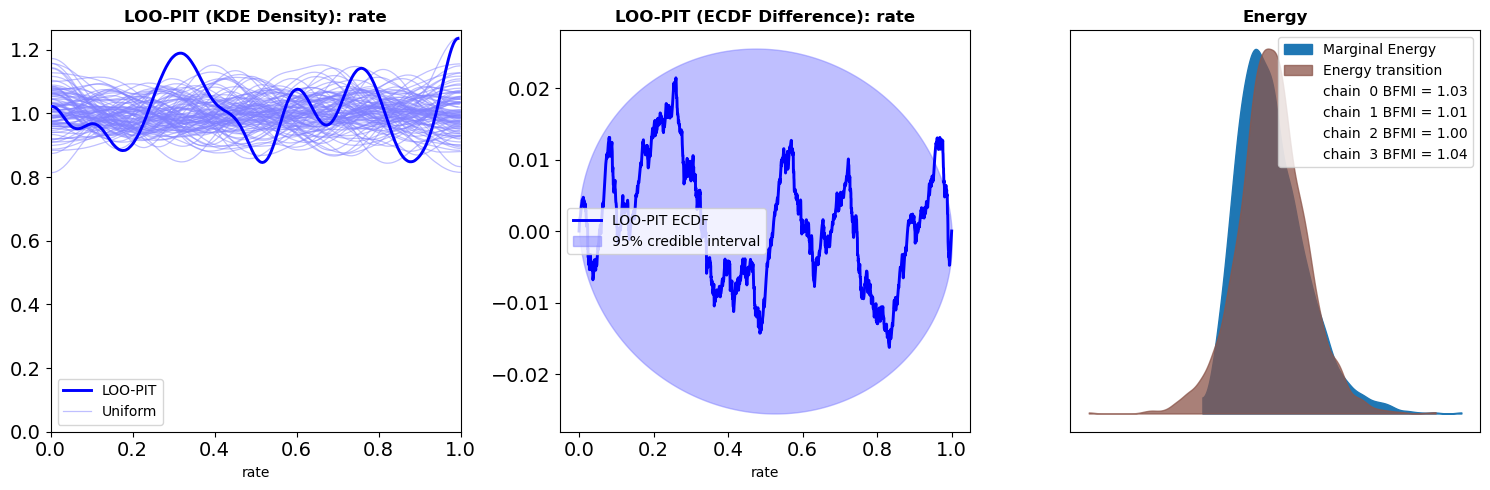

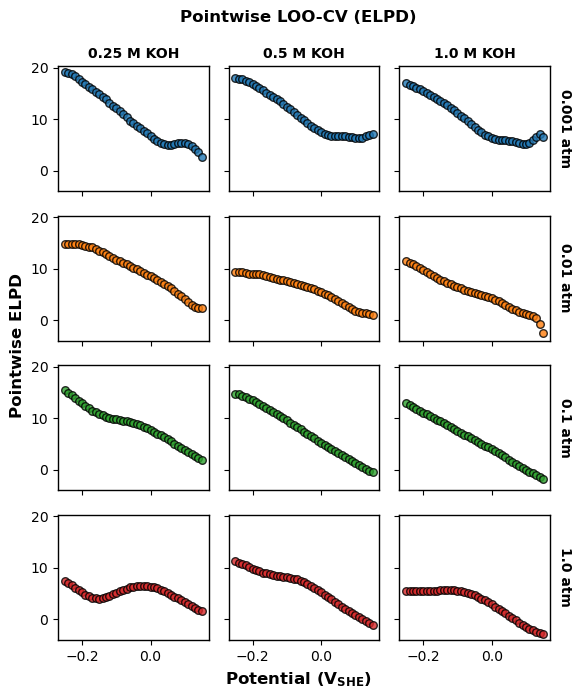

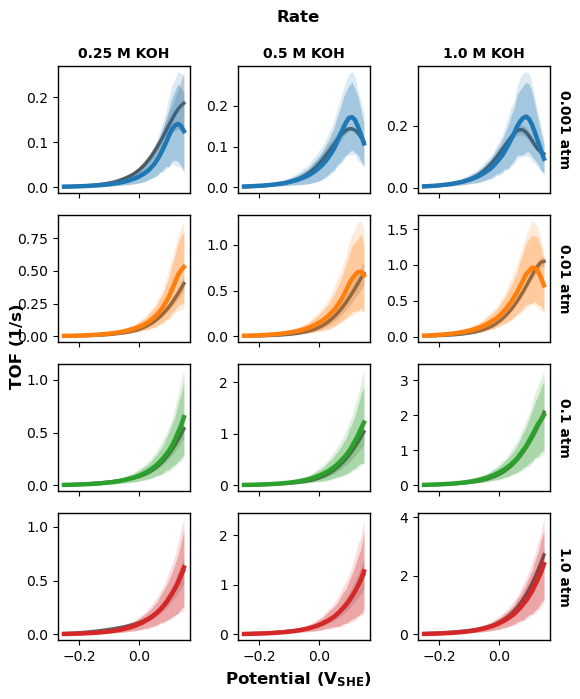

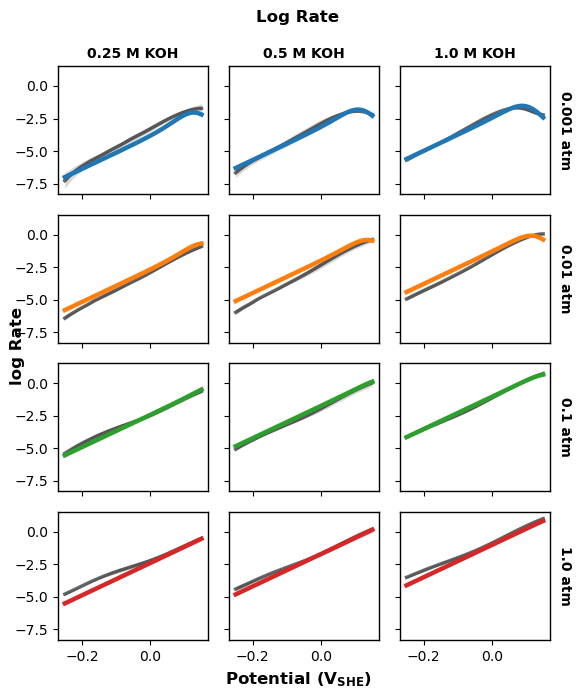

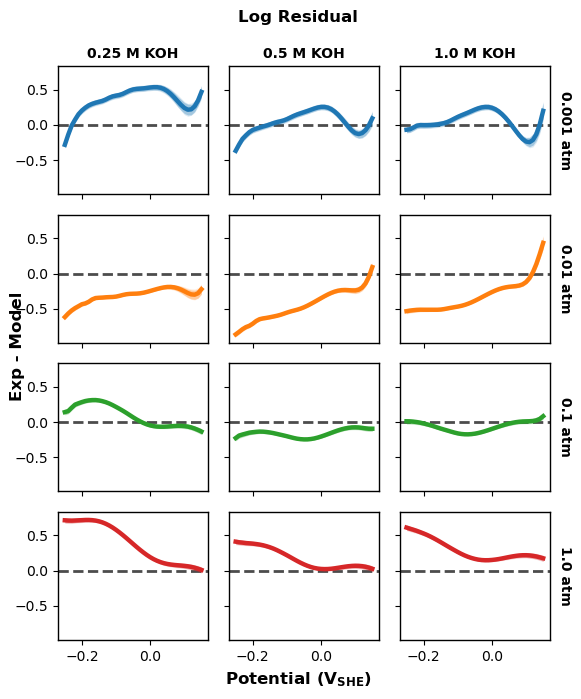

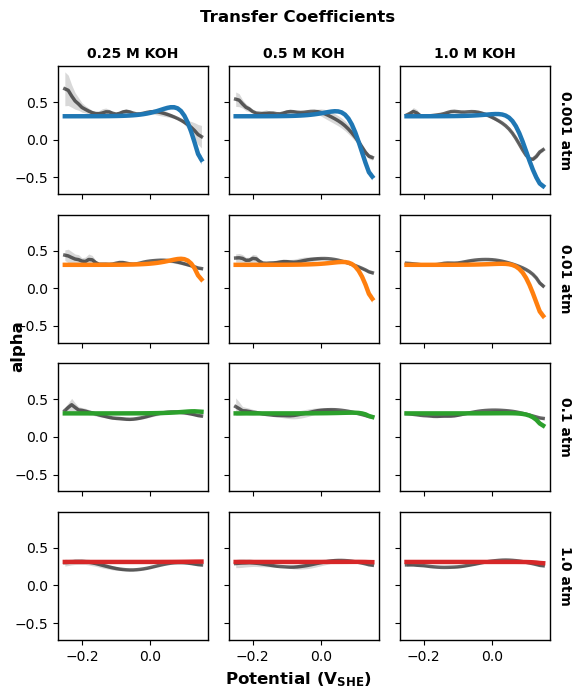

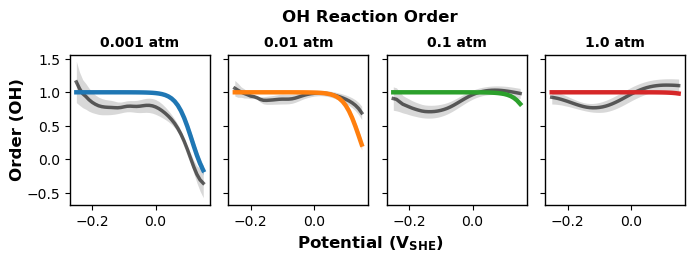

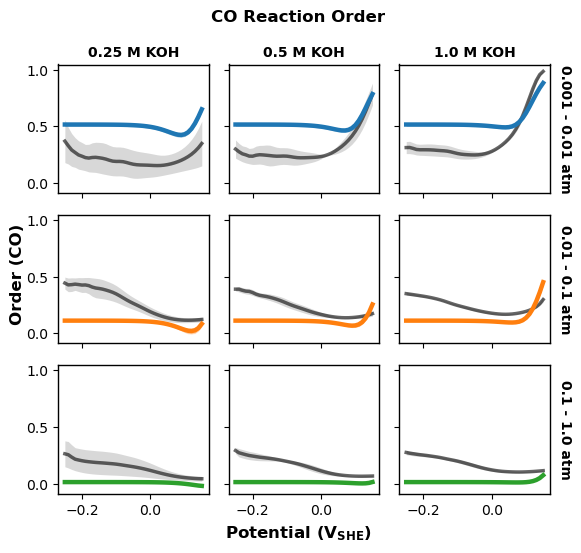

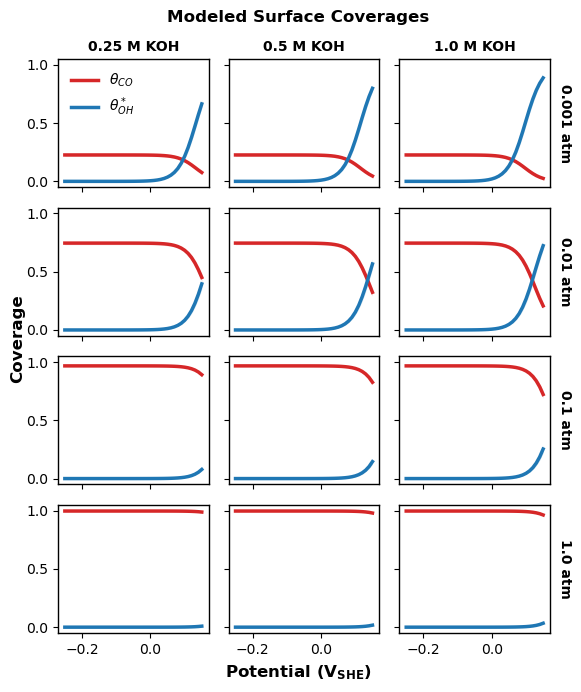

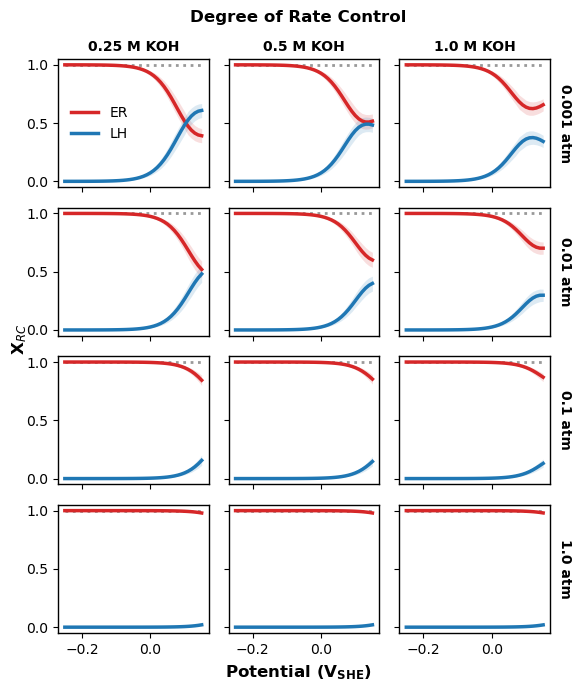

In [3]:
with pm.Model() as LH_ER:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH- -> COOH* + (e-) (RDS)
    2b. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    beta_2 = pm.Uniform('beta_2', lower=0.0, upper=1.0)   
    Gact2_ER_0 = pm.TruncatedNormal('Gact2_ER_0', mu=0.7, sigma=0.2, lower=0.0)
    Gact2_LH_0 = pm.TruncatedNormal('Gact2_LH_0', mu=0.7, sigma=0.2, lower=0.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1-Ag_comp)
    log_rate = pt.logaddexp(log_rate_ER, log_rate_LH)
    rate = observables(log_rate) 

trace_LH_ER, loo_LH_ER = fit_and_evaluate(LH_ER)

ppc_LH_ER = plot_posteriors(trace_LH_ER, LH_ER)
plot_model_fits(trace_LH_ER, ppc_LH_ER, loo_LH_ER); plot_coverages(trace_LH_ER)
plot_drc(LH_ER, trace_LH_ER, perturb_vars=['Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['ER', 'LH'])

# Final

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.18,15
,3000,0,0.23,15
,3000,1,0.21,31
,3000,1,0.21,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  3593.26    58.87
p_loo        5.36        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



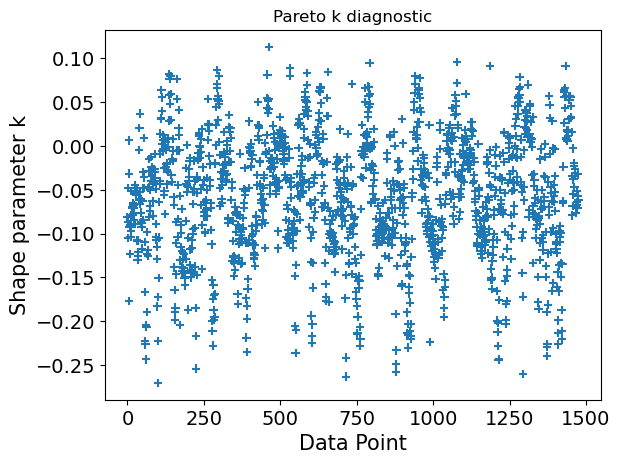

Sampling: [Gact1_0, Gact2_BF_0, Gact2_ER_0, Gact2_LH_0, beta_2_ER, deltaG1_0, deltaG4_0, sigma_rel]


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   0.092  0.002   0.087    0.096      0.000    0.000    2159.0    1529.0    1.0
deltaG1_0  -0.144  0.001  -0.145   -0.142      0.000    0.000    2162.0    2215.0    1.0
beta_2_ER   0.313  0.002   0.308    0.317      0.000    0.000    2430.0    2481.0    1.0
Gact1_0     0.399  0.091   0.225    0.532      0.003    0.003    1015.0     831.0    1.0
Gact2_BF_0  2.001  0.000   2.000    2.001      0.000    0.000    4069.0    2526.0    1.0
Gact2_ER_0  0.769  0.000   0.769    0.770      0.000    0.000    2336.0    2449.0    1.0
Gact2_LH_0  0.736  0.003   0.731    0.741      0.000    0.000    2207.0    2462.0    1.0
sigma_rel   0.310  0.007   0.297    0.322      0.000    0.000    4094.0    2743.0    1.0

--- Prior-to-Posterior Contraction ---
deltaG4_0: 1.000
deltaG1_0: 1.000
beta_2_ER: 1.000
Gact1_0: 0.739
Gact2_BF_0: 0.014
Gact2_ER_0: 1.000
Gact2_LH_0: 1.000
sigma_rel: 0.988


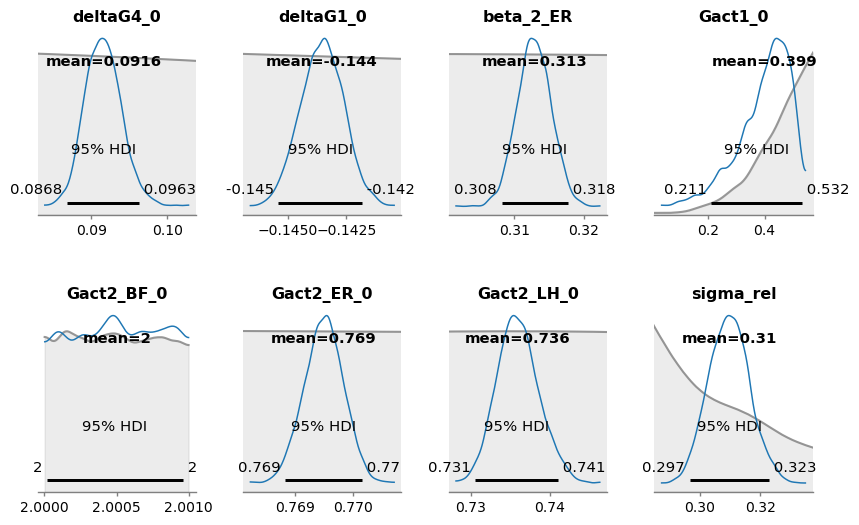

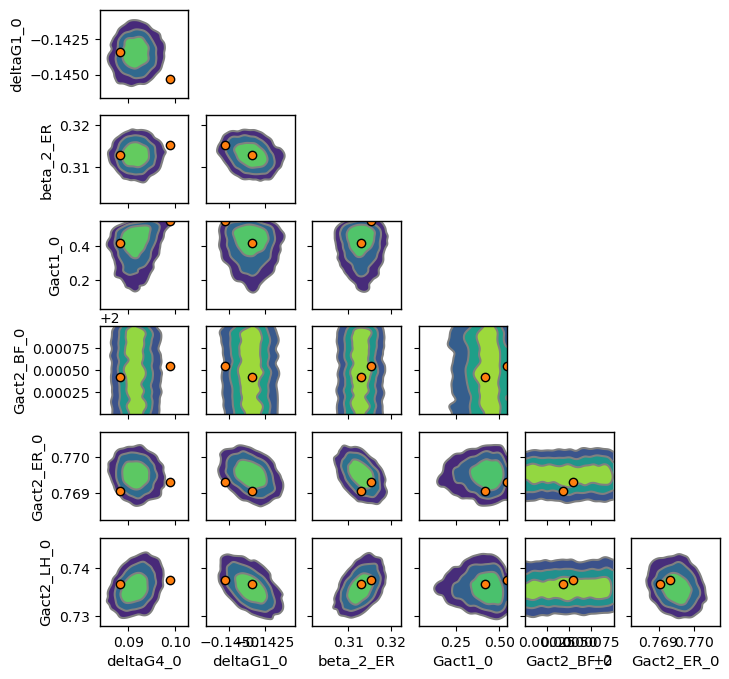

Sampling: [rate]


rate: 0.849


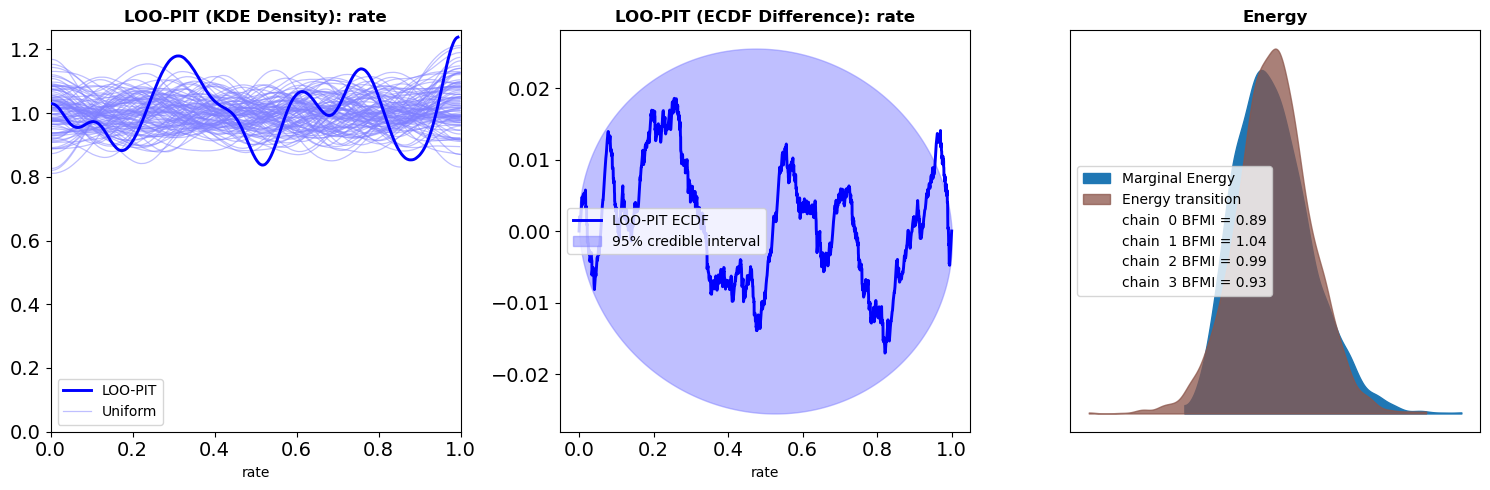

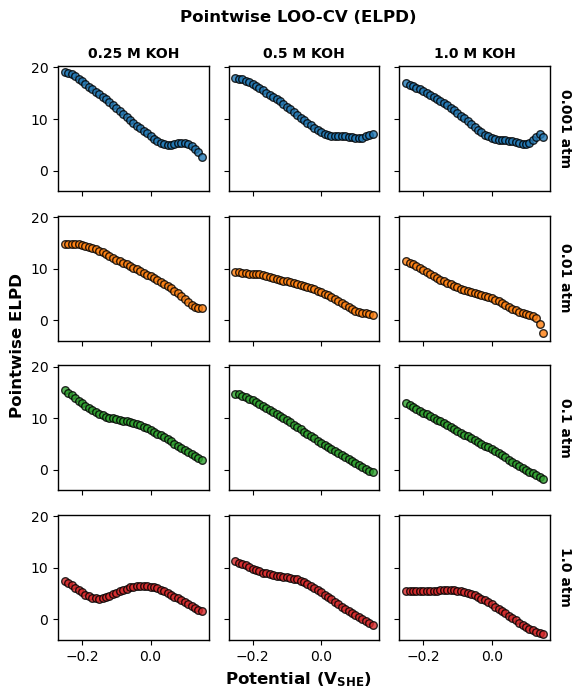

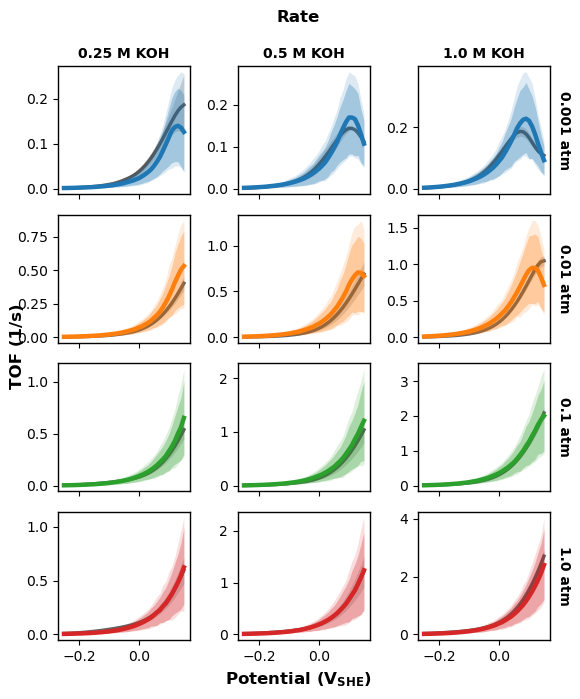

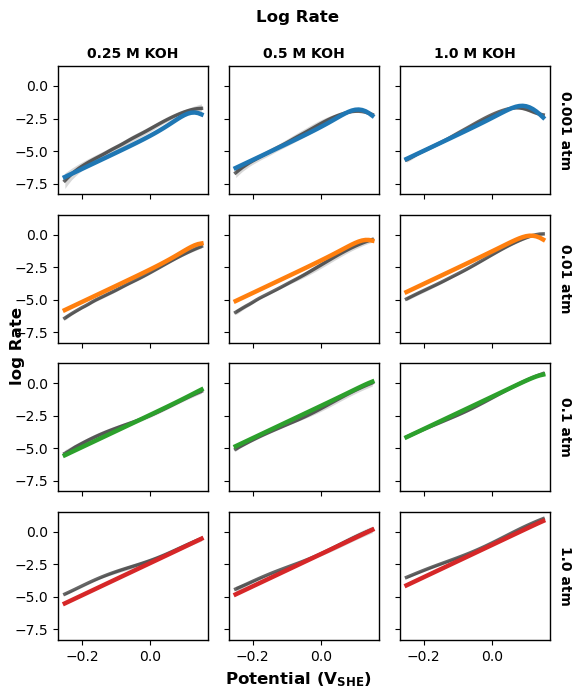

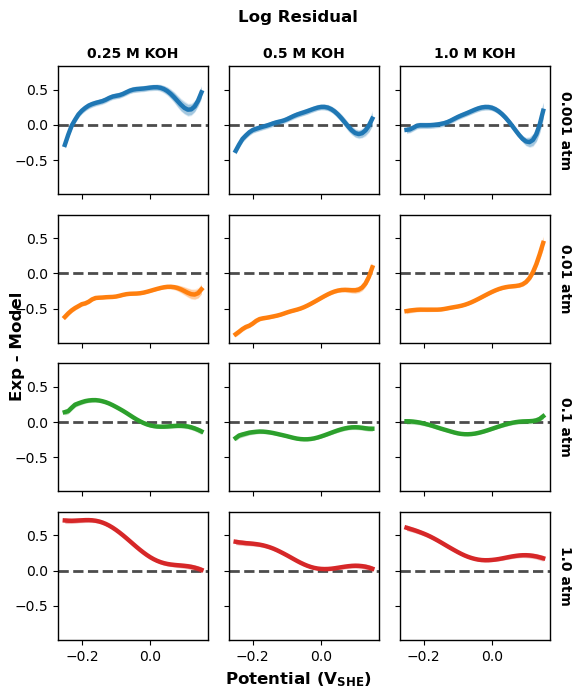

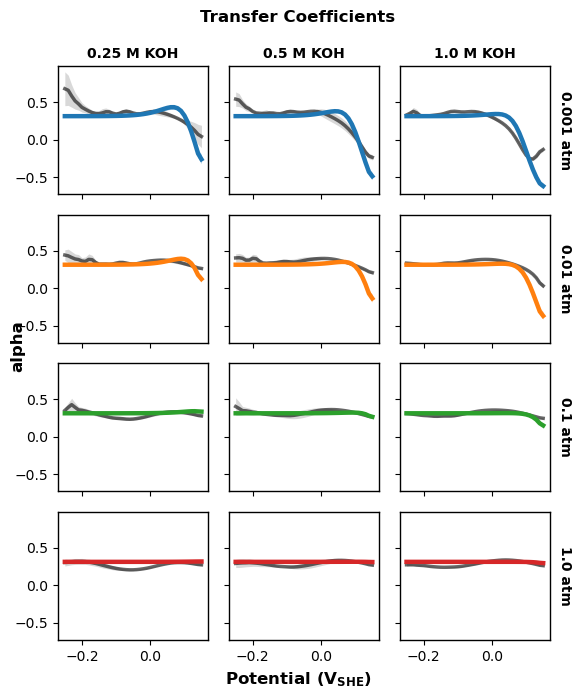

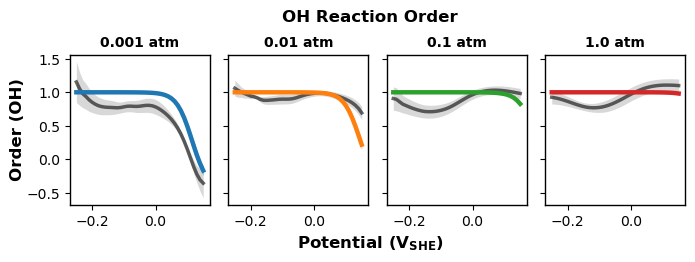

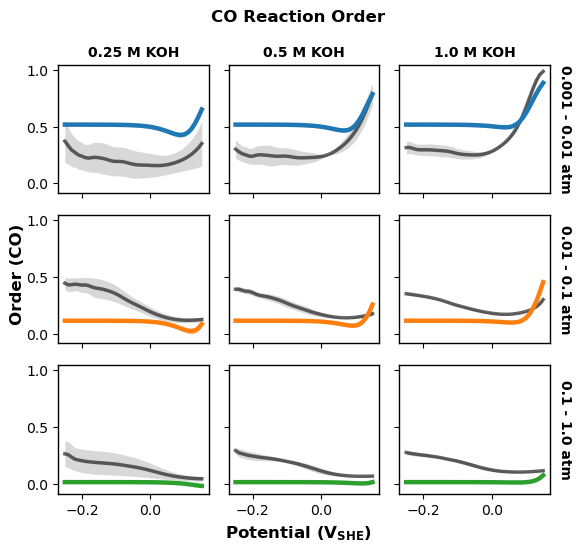

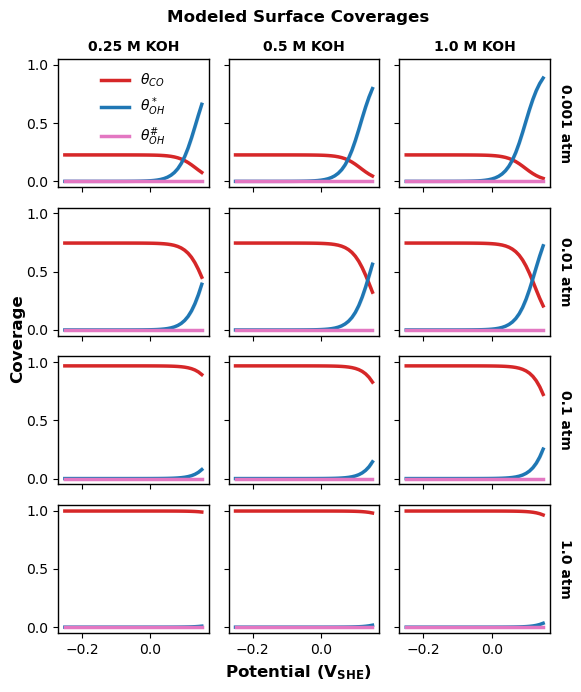

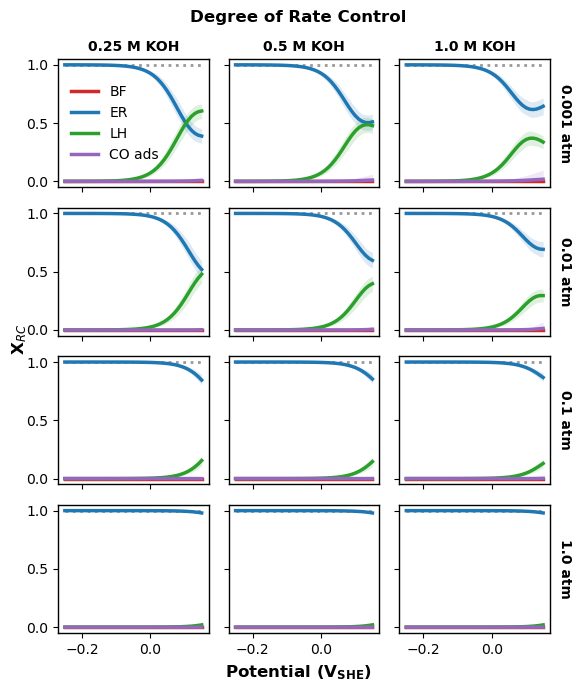

In [4]:
with pm.Model() as CO_BF_ER_LH:
    '''
    1. CO + * <-> CO* (SSA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA) (BF)
    2b. CO* + OH- -> COOH* + * + (e-) (SSA) (ER)
    2c. CO* + OH* -> COOH* + * (SSA) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.4, sigma=0.2, upper=0.0, lower=-0.4)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    deltaG5_0 = 1.0 # pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) 
    beta_2_BF = 0.5 # pm.Uniform('beta_2_BF', lower=0.0, upper=1.0)
    beta_2_ER = pm.Uniform('beta_2_ER', lower=0.0, upper=1.0)
    q = 0.5 # pm.Uniform('q', lower=0.0, upper=1.0)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.7, sigma=0.2, lower=0.0, upper=1.0)
    Gact2_BF_0 = pm.Uniform('Gact2_BF_0', lower=2.0, upper=2.001) # pm.TruncatedNormal('Gact2_BF_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)
    Gact2_ER_0 = pm.TruncatedNormal('Gact2_ER_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)
    Gact2_LH_0 = pm.TruncatedNormal('Gact2_LH_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact1 = Gact1_0
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_OH_Ag)
    log_theta_Ag = -pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    log_A_Pd = pt.logsumexp(pt.stack([zeros, term_OH_Pd]), axis=0) 
    log_k1_PCO = log_k1 + np.log(P_CO_in)                    
    log_k_minus_1 = log_k1 - log_K1                                
    log_k_BF_app = log_k2_BF + log_theta_OH_Ag + np.log(Ag_comp)     
    log_k_ER_app = log_k2_ER + np.log(C_KOH_in)
    log_k_LH_app = log_k2_LH + term_OH_Pd + np.log(1.0 - Ag_comp) 

    # Quadratic solution for empty Pd site fraction
    k1_PCO = pt.exp(log_k1_PCO)
    A_Pd = pt.exp(log_A_Pd)
    log_k_cons = pt.logaddexp(pt.logaddexp(log_k_BF_app, log_k_ER_app), log_k_minus_1)
    k_cons = pt.exp(log_k_cons)
    k_LH_app = pt.exp(log_k_LH_app)
    a = k_LH_app * A_Pd
    b = k1_PCO + k_cons * A_Pd - k_LH_app
    c = -k_cons
    theta_empty_Pd_val = (2 * c) / (-b - pt.sqrt(b**2 - 4 * a * c)) # Analytical solution to quadratic SSA
    log_theta_Pd = pt.log(theta_empty_Pd_val)
    log_theta_CO = pt.log(1.0 - A_Pd * theta_empty_Pd_val)
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_k_total_app = pt.logaddexp(pt.logaddexp(log_k_BF_app, log_k_ER_app), log_k_LH_app + log_theta_Pd) 
    log_rate = log_k_total_app + log_theta_CO
    rate = observables(log_rate)

trace_CO_BF_ER_LH, loo_CO_BF_ER_LH = fit_and_evaluate(CO_BF_ER_LH, target_accept=0.95)

ppc_CO_BF_ER_LH = plot_posteriors(trace_CO_BF_ER_LH, CO_BF_ER_LH)
plot_model_fits(trace_CO_BF_ER_LH, ppc_CO_BF_ER_LH, loo_CO_BF_ER_LH); plot_coverages(trace_CO_BF_ER_LH)
plot_drc(CO_BF_ER_LH, trace_CO_BF_ER_LH, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact2_LH_0', 'Gact1_0'], perturb_labels=['BF', 'ER', 'LH', 'CO ads'])

# Comparison

             rank     elpd_loo     p_loo  elpd_diff  weight         se       dse  warning scale
LH_ER           0  3593.602498  5.164643   0.000000     1.0  58.884626  0.000000    False   log
CO_BF_ER_LH     1  3593.264336  5.358916   0.338162     0.0  58.872084  0.097474    False   log
ER              2  3552.086386  4.692822  41.516112     0.0  59.801210  8.005973    False   log


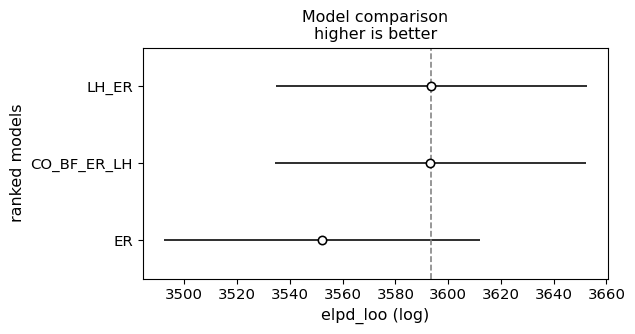

In [5]:
comparison_dict = {    
    "ER": loo_ER,
    "LH_ER": loo_LH_ER,
    "CO_BF_ER_LH": loo_CO_BF_ER_LH
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()